In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter


df2 = pd.read_csv('students_data.csv')

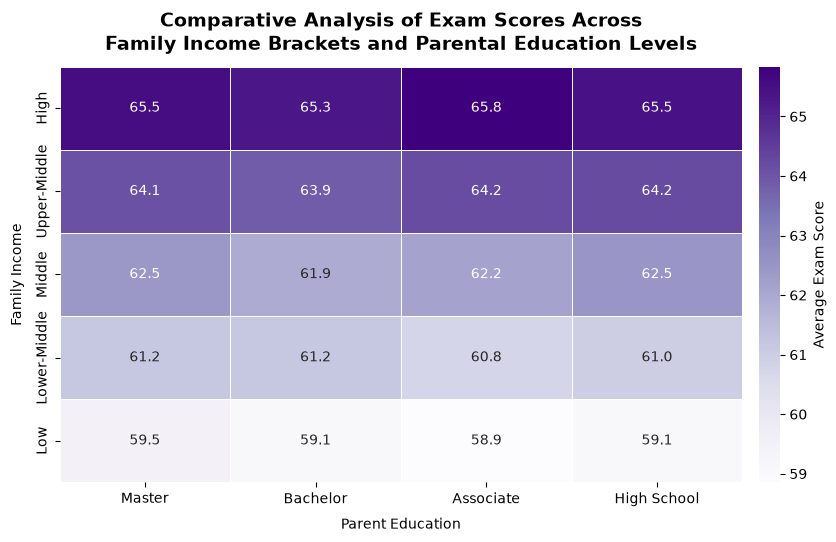

In [19]:
df2["parent_education"] = df2["parent_education"].replace("Unknown", np.nan)

income_order = [
    "High",
    "Upper-Middle",
    "Middle",
    "Lower-Middle",
    "Low"
]

parent_order = [
    "Master",
    "Bachelor",
    "Associate",
    "High School"
]

heatmap_df = (
    df2.groupby(["family_income", "parent_education"])["exam_score"]
       .mean()
       .unstack()
       .reindex(index=income_order, columns=parent_order)
)

plt.figure(figsize=(9, 5.5))

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="Purples",
    linewidths=0.6,
    cbar_kws={
        "label": "Average Exam Score",
        "pad": 0.02
}
)

ax.set_title(
    "Comparative Analysis of Exam Scores Across\n"
    "Family Income Brackets and Parental Education Levels",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Parent Education", labelpad=8)
ax.set_ylabel("Family Income", labelpad=8)

plt.tight_layout(pad=1)
plt.show()